In [1]:
import pandas as pd
import psycopg2
from dotenv import load_dotenv
import os

load_dotenv()

conn = psycopg2.connect(
    host=os.getenv("DB_HOST"),
    port=os.getenv("DB_PORT"),
    dbname=os.getenv("DB_NAME"),
    user=os.getenv("DB_USER"),
    password=os.getenv("DB_PASSWORD")
)

df = pd.read_sql("SELECT * FROM gold_nepse_features", conn)
print(df.shape)
df.head()

C:\Users\utsab\AppData\Local\Temp\ipykernel_21312\716401488.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM gold_nepse_features", conn)


(241916, 9)


,symbol,scraped_date,ltp,price_change,change_pct,avg_7_day,avg_30_day,max_30_day,min_30_day
0,ACLBSL,2024-03-05,608.0,0.0,0.0,608.000000,608.000000,608.0,608.0
1,ACLBSL,2024-03-06,609.5,0.0,0.0,608.750000,608.750000,609.5,608.0
2,ACLBSL,2024-03-07,612.0,0.0,0.0,609.833333,609.833333,612.0,608.0
3,ACLBSL,2024-03-08,612.0,0.0,0.0,610.375000,610.375000,612.0,608.0
4,ACLBSL,2024-03-09,612.0,0.0,0.0,610.700000,610.700000,612.0,608.0


In [2]:
print(df.dtypes)
print(f"\nDate range: {df['scraped_date'].min()} to {df['scraped_date'].max()}")
print(f"Unique stocks: {df['symbol'].nunique()}")
print(f"Unique dates: {df['scraped_date'].nunique()}")

symbol              str
scraped_date     object
ltp             float64
price_change    float64
change_pct      float64
avg_7_day       float64
avg_30_day      float64
max_30_day      float64
min_30_day      float64
dtype: object

Date range: 2024-03-04 to 2026-04-02
Unique stocks: 496
Unique dates: 760


In [3]:
df.isnull().sum()

symbol          0
scraped_date    0
ltp             0
price_change    0
change_pct      0
avg_7_day       0
avg_30_day      0
max_30_day      0
min_30_day      0
dtype: int64

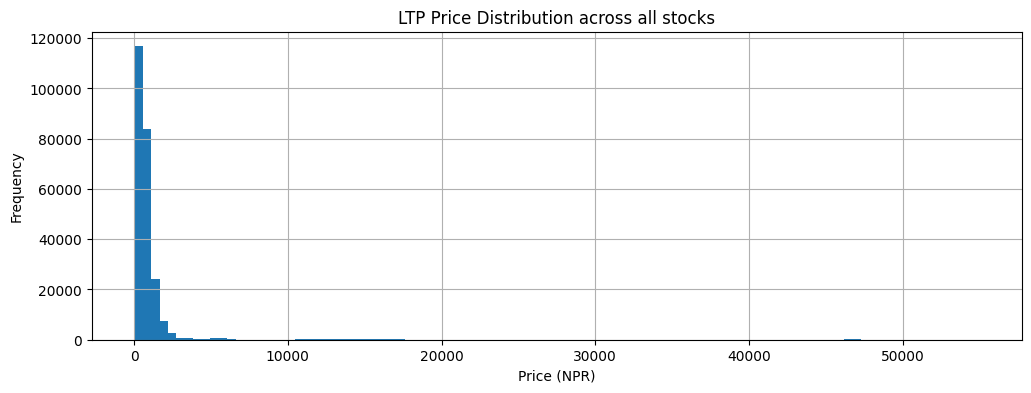

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
df['ltp'].hist(bins=100)
plt.title('LTP Price Distribution across all stocks')
plt.xlabel('Price (NPR)')
plt.ylabel('Frequency')
plt.show()

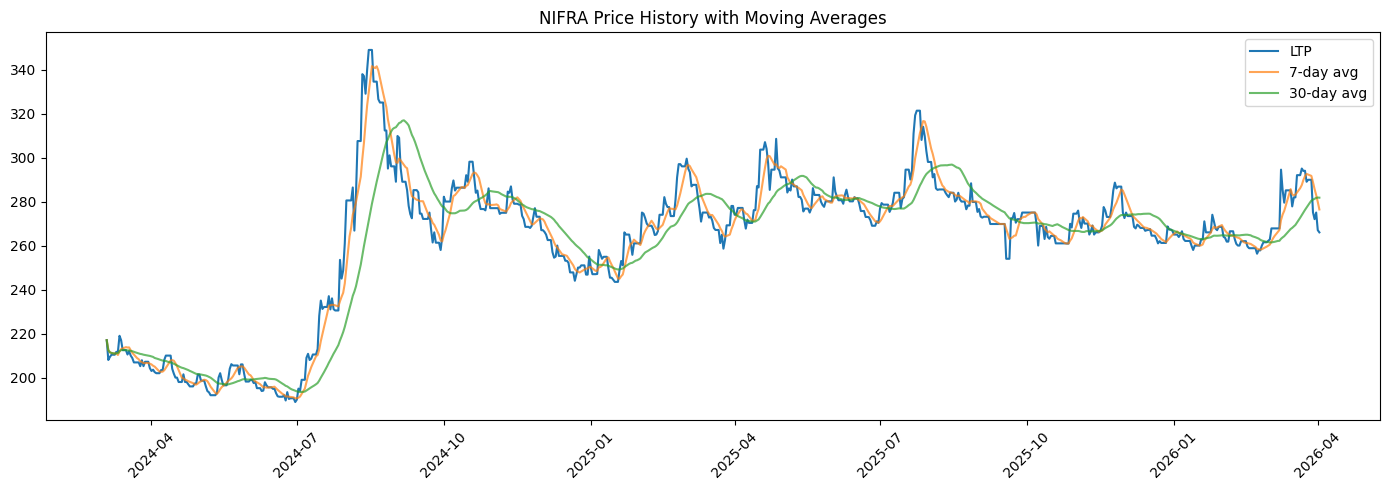

In [5]:
adbl = df[df['symbol'] == 'NIFRA'].sort_values('scraped_date')

plt.figure(figsize=(14, 5))
plt.plot(adbl['scraped_date'], adbl['ltp'], label='LTP')
plt.plot(adbl['scraped_date'], adbl['avg_7_day'], label='7-day avg', alpha=0.7)
plt.plot(adbl['scraped_date'], adbl['avg_30_day'], label='30-day avg', alpha=0.7)
plt.title('NIFRA Price History with Moving Averages')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Cell 6 — which stocks are most volatile?
volatility = df.groupby('symbol')['ltp'].std().sort_values(ascending=False)
print("Top 10 most volatile stocks:")
print(volatility.head(10))

Top 10 most volatile stocks:
symbol
UNL        2857.073524
ANLB       1487.775338
RBCL       1411.276130
BNL        1409.225671
BNT        1288.798972
ULBSL       896.240247
RBCLPO      876.163036
SWASTIK     817.756569
RSML        751.303033
BBC         727.984593
Name: ltp, dtype: float64


In [7]:
# Cell 7 — average price by stock (find expensive vs cheap)
avg_price = df.groupby('symbol')['ltp'].mean().sort_values(ascending=False)
print("Top 10 most expensive stocks on average:")
print(avg_price.head(10))
print("\nTop 10 cheapest stocks on average:")
print(avg_price.tail(10))

Top 10 most expensive stocks on average:
symbol
UNL       46600.776028
BNL       16808.996026
RBCL      15236.477470
BNT       13008.247550
RBCLPO    11931.115310
STC        5371.853794
BBC        4921.368103
ANLB       4857.545860
ULBSL      3172.408228
SAMAJ      2740.829086
Name: ltp, dtype: float64

Top 10 cheapest stocks on average:
symbol
SBCF       9.077635
KSY        9.071725
KEF        9.059004
RMF1       9.050252
NBF3       9.018820
NIBLGF     8.857879
NICGF2     8.732005
NIBLSTF    8.725383
MMF1       8.605812
NIBSF2     8.495099
Name: ltp, dtype: float64


In [8]:
# Cell 8 — how many trading days per stock?
# stocks with fewer days might have been listed recently or delisted
trading_days = df.groupby('symbol')['scraped_date'].nunique().sort_values()
print("Stocks with fewest trading days (possibly new listings):")
print(trading_days.head(10))

Stocks with fewest trading days (possibly new listings):
symbol
SWBBLP    1
SINDUP    1
EDBLPO    1
MLBBLP    1
GMFILP    1
GRDBLP    1
NICLPO    1
PFLPO     1
MMFDBP    1
NILPO     2
Name: scraped_date, dtype: int64


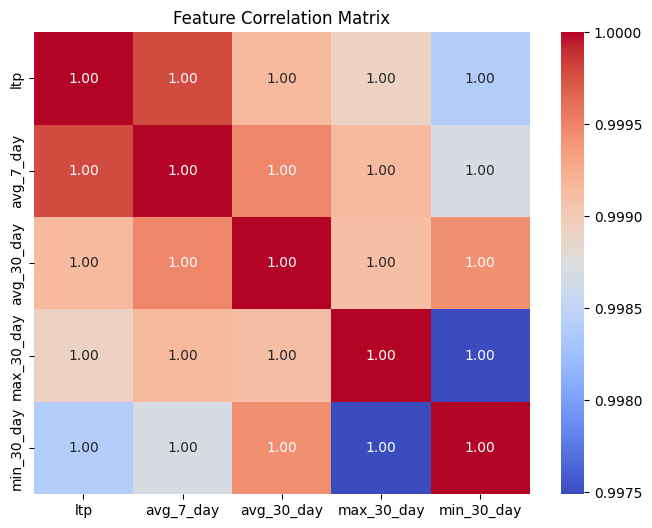

In [9]:
# Cell 9 — correlation between features
# does 7-day avg correlate with 30-day avg? (should be high)
# does change_pct correlate with anything useful?
numeric_cols = ['ltp', 'avg_7_day', 'avg_30_day', 'max_30_day', 'min_30_day']
correlation = df[numeric_cols].corr()

import seaborn as sns
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


In [10]:
# Cell 10 — filter out stocks with less than 100 trading days
sufficient_data = trading_days[trading_days >= 100].index
df_filtered = df[df['symbol'].isin(sufficient_data)]
print(f"Stocks with sufficient data: {df_filtered['symbol'].nunique()}")
print(f"Rows after filtering: {len(df_filtered)}")

Stocks with sufficient data: 389
Rows after filtering: 239775


In [11]:
# Cell 11 — create better features
df_features = df_filtered.copy()

# ratio features — much less correlated
df_features['price_vs_7day'] = df_features['ltp'] / df_features['avg_7_day']
df_features['price_vs_30day'] = df_features['ltp'] / df_features['avg_30_day']
df_features['trend_strength'] = df_features['avg_7_day'] / df_features['avg_30_day']
df_features['price_position'] = (
    (df_features['ltp'] - df_features['min_30_day']) /
    (df_features['max_30_day'] - df_features['min_30_day'] + 0.0001)
)

# check correlation of new features
new_features = ['price_vs_7day', 'price_vs_30day', 'trend_strength', 'price_position']
print(df_features[new_features].corr())

                price_vs_7day  price_vs_30day  trend_strength  price_position
price_vs_7day        1.000000        0.664911        0.286232        0.547851
price_vs_30day       0.664911        1.000000        0.904313        0.721950
trend_strength       0.286232        0.904313        1.000000        0.631265
price_position       0.547851        0.721950        0.631265        1.000000


In [12]:
# Cell 12 — create the target variable
# what we want to predict: will price go up or down tomorrow?
df_features = df_features.sort_values(['symbol', 'scraped_date'])
df_features['next_day_ltp'] = df_features.groupby('symbol')['ltp'].shift(-1)
df_features['target'] = (df_features['next_day_ltp'] > df_features['ltp']).astype(int)
# 1 = price went up next day
# 0 = price went down next day

print(df_features['target'].value_counts())
print(f"\nClass balance: {df_features['target'].mean():.2%} up days")

target
0    172863
1     66912
Name: count, dtype: int64

Class balance: 27.91% up days


In [13]:
# Cell 13 — check class balance per year
df_features['year'] = pd.to_datetime(df_features['scraped_date']).dt.year
print(df_features.groupby('year')['target'].mean())

year
2024    0.290365
2025    0.271781
2026    0.271328
Name: target, dtype: float64


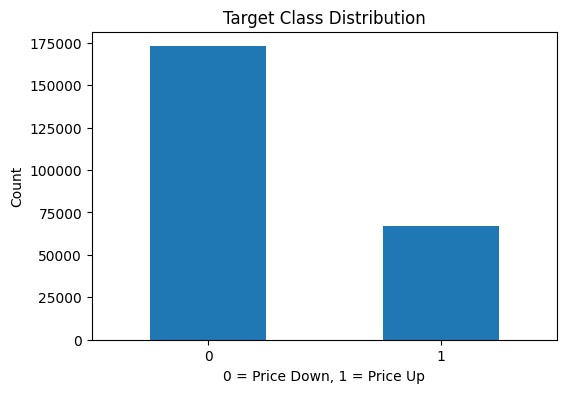

In [14]:
# Cell 14 — visualize class imbalance
plt.figure(figsize=(6, 4))
df_features['target'].value_counts().plot(kind='bar')
plt.title('Target Class Distribution')
plt.xlabel('0 = Price Down, 1 = Price Up')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [15]:
# Cell 15 — drop highly correlated feature
# price_vs_30day and trend_strength are 0.904 correlated
# keep trend_strength, drop price_vs_30day
final_features = ['price_vs_7day', 'trend_strength', 'price_position']
print("Final features selected:", final_features)
print(df_features[final_features].corr())

Final features selected: ['price_vs_7day', 'trend_strength', 'price_position']
                price_vs_7day  trend_strength  price_position
price_vs_7day        1.000000        0.286232        0.547851
trend_strength       0.286232        1.000000        0.631265
price_position       0.547851        0.631265        1.000000


In [16]:
# Cell 16 — measure how long up and down trends last
df_streak = df_features[['symbol', 'scraped_date', 'target']].copy()
df_streak = df_streak.sort_values(['symbol', 'scraped_date'])

# identify streak changes
df_streak['streak_change'] = (
    df_streak.groupby('symbol')['target']
    .transform(lambda x: x != x.shift(1))
)

# assign streak id per symbol
df_streak['streak_id'] = (
    df_streak.groupby('symbol')['streak_change']
    .cumsum()
)

# count streak lengths
streak_lengths = (
    df_streak.groupby(['symbol', 'streak_id', 'target'])
    .size()
    .reset_index(name='length')
)

# separate up and down streaks
up_streaks = streak_lengths[streak_lengths['target'] == 1]['length']
down_streaks = streak_lengths[streak_lengths['target'] == 0]['length']

print("UP streak statistics:")
print(up_streaks.describe())
print(f"\nDOWN streak statistics:")
print(down_streaks.describe())

UP streak statistics:
count    45538.000000
mean         1.469366
std          0.790280
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          8.000000
Name: length, dtype: float64

DOWN streak statistics:
count    45823.000000
mean         3.772407
std          2.903844
min          1.000000
25%          2.000000
50%          3.000000
75%          5.000000
max         43.000000
Name: length, dtype: float64


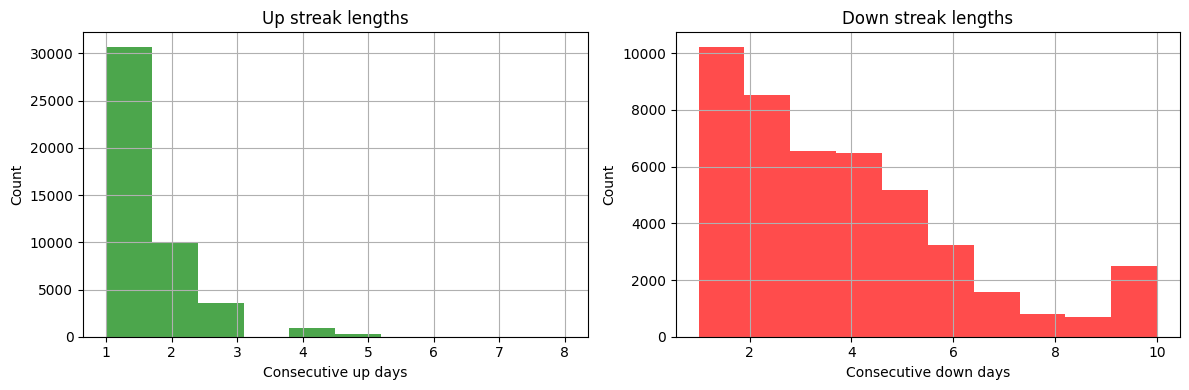

In [17]:
# Cell 17 — visualize streak distributions
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
up_streaks.clip(upper=10).hist(bins=10, color='green', alpha=0.7)
plt.title('Up streak lengths')
plt.xlabel('Consecutive up days')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
down_streaks.clip(upper=10).hist(bins=10, color='red', alpha=0.7)
plt.title('Down streak lengths')
plt.xlabel('Consecutive down days')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [18]:
# Cell 18 — test a 5-day forward looking target
df_features = df_features.sort_values(['symbol', 'scraped_date'])

# price 5 trading days from now
df_features['ltp_5day_forward'] = (
    df_features.groupby('symbol')['ltp'].shift(-5)
)

# did price go up over the next 5 days?
df_features['target_5day'] = (
    df_features['ltp_5day_forward'] > df_features['ltp']
).astype(int)

print("5-day target class balance:")
print(df_features['target_5day'].value_counts())
print(f"Up days: {df_features['target_5day'].mean():.2%}")

5-day target class balance:
target_5day
0    129107
1    110668
Name: count, dtype: int64
Up days: 46.15%


In [19]:
# Cell 19 — compare 1-day vs 5-day target balance
print("1-day target:")
print(f"  Up: {df_features['target'].mean():.2%}")
print(f"  Down: {1-df_features['target'].mean():.2%}")

print("\n5-day target:")
print(f"  Up: {df_features['target_5day'].mean():.2%}")
print(f"  Down: {1-df_features['target_5day'].mean():.2%}")

1-day target:
  Up: 27.91%
  Down: 72.09%

5-day target:
  Up: 46.15%
  Down: 53.85%


In [20]:
# Cell 20 — prepare final training dataset
from datetime import date

# use 2025 onwards only — 2024 has unreliable change_pct
df_model = df_features[
    pd.to_datetime(df_features['scraped_date']).dt.year >= 2025
].copy()

# drop rows where target is NaN (last 5 rows per stock have no forward price)
df_model = df_model.dropna(subset=['target_5day', 'price_vs_7day', 
                                    'trend_strength', 'price_position'])

print(f"Training dataset shape: {df_model.shape}")
print(f"Date range: {df_model['scraped_date'].min()} to {df_model['scraped_date'].max()}")
print(f"Stocks: {df_model['symbol'].nunique()}")
print(f"Class balance: {df_model['target_5day'].mean():.2%} up")
print(f"\nNull check:")
print(df_model[['price_vs_7day', 'trend_strength', 
                 'price_position', 'target_5day']].isnull().sum())

Training dataset shape: (145108, 18)
Date range: 2025-01-01 to 2026-04-02
Stocks: 382
Class balance: 43.88% up

Null check:
price_vs_7day     0
trend_strength    0
price_position    0
target_5day       0
dtype: int64
